In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.points import add_points_features
from src.models.evaluation import score_role_distribution
from src.models.xgboost_models.artifact_bundle import (
    load_joint_points_bundle,
)
from src.models.xgboost_models.joint_simulation import (
    JointPointsSimulator,
)

HOLDOUT_SEASON = "2025-26"
N_DRAWS = 2_000
# Set to an int for a smoke test; None scores the full holdout.
MAX_ROWS = None
SEASONS = [
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26",
]

In [2]:
frames = []
for season in SEASONS:
    path = (
        ROOT
        / "data"
        / "silver"
        / "nba"
        / season
        / "regular_season"
        / "player_gamelogs.parquet"
    )
    frames.append(pd.read_parquet(path))

panel = pd.concat(frames, ignore_index=True)
panel = add_points_features(panel)
appearances = panel.loc[panel["minutes"].gt(0)].copy()
appearances["game_date"] = pd.to_datetime(appearances["game_date"])
holdout = appearances.loc[
    appearances["season_year"].astype("string").eq(HOLDOUT_SEASON)
].copy()
if MAX_ROWS is not None:
    holdout = (
        holdout.sort_values("game_date").tail(int(MAX_ROWS))
    )

print(f"Holdout appearances: {len(holdout):,}")
print(
    f"{holdout['game_date'].min().date()} → "
    f"{holdout['game_date'].max().date()}"
)
del frames, panel, appearances

Holdout appearances: 26,648
2025-10-21 → 2026-04-12


In [3]:
bundle = load_joint_points_bundle(
    minutes_mean_path=(
        ROOT / "artifacts" / "models" / "minutes" / "xgboost_minutes.joblib"
    ),
    minutes_dist_path=(
        ROOT
        / "artifacts"
        / "models"
        / "minutes"
        / "xgboost_minutes_distribution.joblib"
    ),
    points_path=(
        ROOT / "artifacts" / "models" / "points" / "xgboost_points.joblib"
    ),
    joint_calibration_path=(
        ROOT
        / "artifacts"
        / "models"
        / "points"
        / "joint_calibration.joblib"
    ),
)
sim = JointPointsSimulator(bundle, n_draws=N_DRAWS)

# Do not call simulate() then np.stack, and do not compute CRPS.
# Full holdout x 2,000 draws x pairwise CRPS is ~(n, 2000, 2000) RAM.
samples = sim.simulate_points(holdout)
metrics = score_role_distribution(
    samples,
    holdout["pts"].to_numpy(dtype=float),
    holdout["start_rate_10"].to_numpy(dtype=float),
    include_crps=False,
)
pd.Series(metrics)

negative_log_likelihood        2.986767
coverage_80                    0.810455
width_80                      13.928227
pit_mean                       0.476932
pit_std                        0.296974
pit_shape                      0.052559
starter_coverage               0.794810
bench_coverage                 0.822591
gap                            0.027781
n_starter                  11945.000000
n_bench                    14599.000000
dtype: float64

## Holdout PIT deciles

Uniform PIT would put 10% of appearances in each decile. Mean PIT target is 0.50.

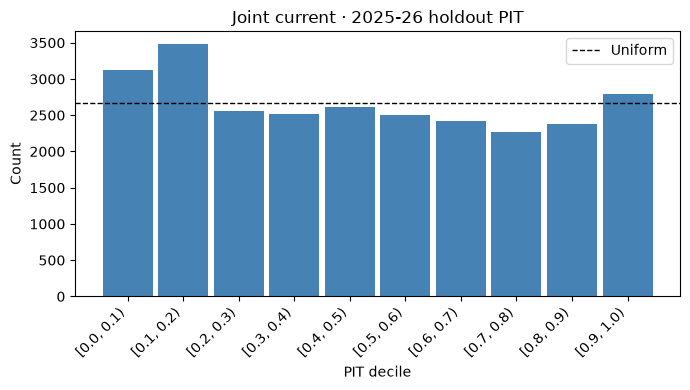

PIT mean=0.4769  std=0.2970  n=26,648


,decile,count,share,expected_share,share_minus_uniform
0,"[0.0, 0.1)",3126,0.117307,0.1,0.017307
1,"[0.1, 0.2)",3483,0.130704,0.1,0.030704
2,"[0.2, 0.3)",2564,0.096217,0.1,-0.003783
3,"[0.3, 0.4)",2514,0.094341,0.1,-0.005659
4,"[0.4, 0.5)",2609,0.097906,0.1,-0.002094
5,"[0.5, 0.6)",2500,0.093816,0.1,-0.006184
6,"[0.6, 0.7)",2425,0.091001,0.1,-0.008999
7,"[0.7, 0.8)",2263,0.084922,0.1,-0.015078
8,"[0.8, 0.9)",2378,0.089237,0.1,-0.010763
9,"[0.9, 1.0)",2786,0.104548,0.1,0.004548


In [4]:
import matplotlib.pyplot as plt

from src.models.evaluation import probability_integral_transform
from src.models.xgboost_models.joint_variant_eval import pit_decile_table

actual = holdout["pts"].to_numpy(dtype=float)
pit = probability_integral_transform(samples, actual)
deciles = pit_decile_table(pit, bins=10)
expected = len(pit) / 10

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    np.arange(10),
    deciles["count"],
    width=0.9,
    color="steelblue",
    align="center",
)
ax.axhline(
    expected,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Uniform",
)
ax.set_xticks(np.arange(10))
ax.set_xticklabels(deciles["decile"], rotation=45, ha="right")
ax.set_xlabel("PIT decile")
ax.set_ylabel("Count")
ax.set_title("Joint current · 2025-26 holdout PIT")
ax.legend()
fig.tight_layout()
plt.show()

print(f"PIT mean={pit.mean():.4f}  std={pit.std():.4f}  n={len(pit):,}")
deciles

## Mean signed error by predicted-points and minutes bands

Signed error is actual points minus the joint predictive mean. Bands use the same ε / minutes edges as coupling. `hat_p` and `hat_m` are the production booster means (one batch pass, not a second 26k-row simulation).

In [5]:
from IPython.display import display

from src.models.xgboost_models.joint_calibration import (
    DEFAULT_MINUTES_BINS,
    EPSILON_BINS,
)
from src.models.xgboost_models.joint_variant_eval import signed_error_by_band

actual = holdout["pts"].to_numpy(dtype=float)
hat_m = sim.predict_minutes_means(holdout)
hat_p = sim.predict_points_means(holdout, hat_m=hat_m)
pred_points = samples.mean(axis=1)

points_bands = signed_error_by_band(
    actual,
    pred_points,
    centers=hat_p,
    edges=EPSILON_BINS,
)
minutes_bands = signed_error_by_band(
    actual,
    pred_points,
    centers=hat_m,
    edges=DEFAULT_MINUTES_BINS,
)

print("Predicted-points bands (ε edges on hat_p)")
display(points_bands.round(3))
print("Minutes bands (hat_m)")
display(minutes_bands.round(3))
print(
    "Overall mean signed error "
    f"{float(np.mean(actual - pred_points)):.4f}"
)

Predicted-points bands (ε edges on hat_p)


,band,n,mean_actual,mean_predicted,mean_signed_error
0,"[0, 8)",10771,4.913,5.260,-0.347
1,"[8, 14)",9114,10.915,10.928,-0.013
2,"[14, 20)",4034,16.592,16.786,-0.194
3,"[20, 28)",2365,22.995,23.259,-0.264
4,"[28, ∞)",364,29.352,30.196,-0.844


Minutes bands (hat_m)


,band,n,mean_actual,mean_predicted,mean_signed_error
0,"[0, 12)",3819,3.017,3.550,-0.532
1,"[12, 18)",4639,5.789,6.023,-0.234
2,"[18, 24)",5688,8.710,8.797,-0.087
3,"[24, 30)",6787,12.592,12.660,-0.068
4,"[30, 36)",5386,19.049,19.321,-0.272
5,"[36, 64)",329,25.578,25.659,-0.081


Overall mean signed error -0.2090


## Holdout `residual_around_p` NLL on identical rows

ε pools are fit on the sealed preholdout OOF panel (`g=0`, `β=0`, global location-corrected residuals). Draws are `max(0, hat_p + ε)` on the same holdout `hat_p` used above. No CRPS.

In [6]:
from src.models.xgboost_models.joint_variant_eval import (
    EVAL_SEED,
    OOF_PANEL_ARTIFACT,
    fit_preholdout_variant,
    load_oof_panel,
    simulate_residual_around_p,
)

oof = load_oof_panel(OOF_PANEL_ARTIFACT)
epsilon = fit_preholdout_variant(oof, "residual_around_p")
residual_samples = simulate_residual_around_p(
    hat_p,
    epsilon,
    n_draws=N_DRAWS,
    seed=EVAL_SEED,
)
residual_metrics = score_role_distribution(
    residual_samples,
    actual,
    holdout["start_rate_10"].to_numpy(dtype=float),
    include_crps=False,
)
compare = pd.DataFrame(
    {
        "current": pd.Series(metrics),
        "residual_around_p": pd.Series(residual_metrics),
    }
)
compare["delta_vs_current"] = (
    compare["residual_around_p"] - compare["current"]
)
del residual_samples, oof, epsilon
compare

,current,residual_around_p,delta_vs_current
negative_log_likelihood,2.986767,3.012533,0.025766
coverage_80,0.810455,0.798747,-0.011708
width_80,13.928227,13.511079,-0.417148
pit_mean,0.476932,0.485794,0.008862
pit_std,0.296974,0.299863,0.002889
pit_shape,0.052559,0.058353,0.005794
starter_coverage,0.794810,0.725827,-0.068983
bench_coverage,0.822591,0.857456,0.034865
gap,0.027781,0.131629,0.103848
n_starter,11945.000000,11945.000000,0.000000


## Location bias diagnostics

Load `artifacts/models/points/location_diagnostics.json` from `scripts/diagnose_points_location.py`. Holdout revealed the clipping hypothesis and cannot independently validate a promotion.


In [ ]:
from pathlib import Path
import json

from IPython.display import display

diag_path = (
    ROOT / "artifacts" / "models" / "points" / "location_diagnostics.json"
)
diag = json.loads(diag_path.read_text())
holdout = diag["holdout"]
pre = diag["preholdout"]

print("Holdout location components")
display(pd.Series(holdout["location"]).to_frame("value").round(4))
print("Holdout PIT: half-credit vs randomized")
display(pd.Series(holdout["pit"]).to_frame("value").round(4))
print("Clipping uplift by hat_p")
display(pd.DataFrame(holdout["clipping_by_hat_p"]).round(3))

In [ ]:
print("Current vs clip-mean match (holdout, not a promotion set)")
holdout_compare = pd.DataFrame(
    {
        "current": pd.Series(holdout["metrics"]),
        "clip_match": pd.Series(holdout["clip_match_metrics"]),
    }
)
holdout_compare["delta"] = (
    holdout_compare["clip_match"] - holdout_compare["current"]
)
display(
    holdout_compare.loc[
        [
            "nll",
            "coverage_80",
            "width_80",
            "pit_mean",
            "pit_shape",
            "role_gap",
        ]
    ].round(4)
)

print("Preholdout expanding folds")
fold_rows = []
for row in pre["folds"]:
    fold_rows.append(
        {
            "fold": row["fold"],
            "n": row["n"],
            "nll_delta": row["nll_delta"],
            "width_ratio": row["width_ratio"],
            "pit_current": row["current"]["pit_mean"],
            "pit_match": row["clip_match"]["pit_mean"],
            "cov_match": row["clip_match"]["coverage_80"],
            "gap_match": row["clip_match"]["role_gap"],
            "clipping_uplift": row["location"]["clipping_uplift"],
            "error_post": row["location"]["error_vs_post_clip"],
        }
    )
display(pd.DataFrame(fold_rows).round(4))
print(f"NLL wins {pre['nll_wins']} / {pre['n_folds']}")

## NBA_US odds snapshots

Grade frozen `current` on `data/odds/NBA_US_20260210_144744.csv` and `data/odds/NBA_US_20260325_131922.csv`. Features use box scores **strictly before** the pull date. The displayed test **omits the pull date and same-day games labeled the next UTC day**.


In [ ]:
from src.features.points.pregame import appearances_before
from src.models.xgboost_models.example_set import (
    ROOT,
    load_player_points_quotes,
    load_silver_panel,
    settle_priced_player_points,
    snapshot_as_of,
)

panel = load_silver_panel()
jobs = [
    (
        ROOT / "data" / "odds" / "NBA_US_20260210_144744.csv",
        ROOT / "artifacts/pricing/nba_us_20260210_player_points.csv",
    ),
    (
        ROOT / "data" / "odds" / "NBA_US_20260325_131922.csv",
        ROOT / "artifacts/pricing/nba_us_20260325_player_points.csv",
    ),
]
summaries = []
for quotes_path, priced_path in jobs:
    quotes = load_player_points_quotes(quotes_path)
    as_of = snapshot_as_of(quotes)
    history_max = appearances_before(panel, as_of)["game_date"].max()
    priced = pd.read_csv(priced_path)
    graded = settle_priced_player_points(
        priced, quotes, panel, as_of=as_of
    )
    settled = graded.loc[graded["grade"].isin(["win", "loss"])]
    n = len(settled)
    summaries.append(
        {
            "as_of": str(as_of.date()),
            "history_max": str(pd.Timestamp(history_max).date()),
            "displayed_game_dates": (
                sorted(
                    pd.to_datetime(graded["game_date"])
                    .dt.date.astype(str)
                    .unique()
                )
                if not graded.empty
                else []
            ),
            "displayed_markets": int(len(graded)),
            "settled": int(n),
            "voids": int((graded["grade"] == "void").sum())
            if not graded.empty
            else 0,
            "wins": int((settled["grade"] == "win").sum()),
            "losses": int((settled["grade"] == "loss").sum()),
            "roi": (
                float(settled["profit"].sum() / n) if n else None
            ),
        }
    )
    if n:
        print(f"{as_of.date()} settled bets (pull date hidden)")
        display(
            settled.sort_values("profit", ascending=False)[
                [
                    "player_name",
                    "book",
                    "line",
                    "selected_side",
                    "hat_p",
                    "pts",
                    "grade",
                    "profit",
                ]
            ]
            .head(12)
            .round(3)
        )
    else:
        print(f"{as_of.date()}: nothing to display after hiding the pull date")

display(pd.DataFrame(summaries))